# TP3 — Diferenciador: Análisis Temporal de Tópicos (BERTopic)

**Alumno:** Gonzalo Zarazaga

---

Más allá de los enfoques pedidos, este notebook busca un diferenciador (a pedido de la cátedra: "salir de lo típico, buscar una alternativa"): usar **BERTopic** para detectar tópicos en los tweets y ver si sus picos de volumen en el tiempo coinciden con eventos reales del período cubierto por el dataset (abril–junio 2009).

BERTopic usa similitud coseno internamente (en `c-TF-IDF` y en la reducción UMAP, acá configurada explícitamente con `metric="cosine"`), por lo que también aporta a la métrica obligatoria del TP.

**Insumo:** `data/processed/train_processed.csv.gz`, `data/raw/training.1600000.processed.noemoticon.csv` (para recuperar la fecha, que no se persistió en el processed)
**Salida:** hallazgos sobre picos temáticos vs. eventos reales, y una corrección a la hipótesis planteada en el README/`00_lectura_y_discovery.ipynb`

## 1. Carga de datos y muestreo

`train_processed.csv.gz` no conserva la columna `date` (se descartó en `01_preprocesamiento.ipynb` por no ser necesaria para clasificación). Se recupera desde el archivo raw y se une por `id`.

**Por qué una muestra y no los 1.6M completos:** BERTopic necesita generar un embedding denso (`sentence-transformers`) por tweet antes de clusterizar. A \~370 tweets/seg en CPU, embeber el corpus completo tomaría más de una hora — inviable para este análisis exploratorio. Se usa una muestra aleatoria de 80.000 tweets (\~5% del corpus), que mantiene densidad diaria suficiente (\~1.000 tweets/día en promedio) para detectar picos temáticos sin comprometer el tiempo de ejecución.

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP

RANDOM_STATE = 42
SAMPLE_N = 80000

COLS = ["polarity", "id", "date", "query", "user", "text"]
raw_fechas = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="latin-1", names=COLS, usecols=["id", "date"],
)

df = pd.read_csv("../data/processed/train_processed.csv.gz")
df = df.merge(raw_fechas, on="id", how="left")
df["date"] = pd.to_datetime(df["date"].str.replace(" PDT", "", regex=False), format="%a %b %d %H:%M:%S %Y")

sample = df.sample(SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Muestra: {len(sample):,} tweets")
print(f"Rango de fechas: {sample['date'].min()} -> {sample['date'].max()}")

Muestra: 80,000 tweets
Rango de fechas: 2009-04-06 22:21:04 -> 2009-06-25 10:28:26


## 2. Embeddings y modelo de tópicos

Se usa `all-MiniLM-L6-v2` (sentence-transformers): liviano, rápido en CPU y suficiente para clustering temático — no hace falta un modelo grande para esto.

**Nota de reproducibilidad:** `BERTopic` usa `UMAP` con estado aleatorio por defecto para reducir dimensionalidad antes de clusterizar. Sin fijar `random_state`, la numeración de tópicos cambia entre corridas (se comprobó al armar este notebook: el mismo tópico de Irán apareció como ID distinto en dos ejecuciones separadas). Se fija `random_state=42` explícitamente en el `UMAP` interno para que el resultado sea reproducible.

In [2]:
model_embeddings = SentenceTransformer("all-MiniLM-L6-v2")

t0 = time.time()
embeddings = model_embeddings.encode(sample["text"].tolist(), batch_size=128, show_progress_bar=False)
print(f"Embeddings: {time.time() - t0:.1f}s, shape {embeddings.shape}")

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_STATE)

t0 = time.time()
topic_model = BERTopic(embedding_model=model_embeddings, umap_model=umap_model, calculate_probabilities=False, verbose=False)
topics, _ = topic_model.fit_transform(sample["text"].tolist(), embeddings)
sample["topic"] = topics
print(f"BERTopic fit: {time.time() - t0:.1f}s")

info = topic_model.get_topic_info()
n_outliers = (sample["topic"] == -1).sum()
print(f"Tópicos encontrados: {len(info) - 1} (+ tópico -1 de outliers, {n_outliers:,} tweets)")
info.head(10)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings: 85.0s, shape (80000, 384)


BERTopic fit: 68.5s
Tópicos encontrados: 649 (+ tópico -1 de outliers, 41,165 tweets)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,41165,-1_and_the_in_to,"[and, the, in, to, it, with, was, that, at, of]","[I get to see my love tonight , Back in my roo..."
1,0,2286,0_twitter_tweet_tweets_tweeting,"[twitter, tweet, tweets, tweeting, twittering,...","[twitter twitter twitter like a little bird , ..."
2,1,1238,1_sleep_bed_goodnight_tired,"[sleep, bed, goodnight, tired, awake, nap, ear...","[i can not sleep and im really tired , Tired b..."
3,2,709,2_agree_yes_know_yeah,"[agree, yes, know, yeah, true, lol, exactly, r...",[@jonfun how? what? who? where? huh? what do y...
4,3,657,3_thank_thanks_welcome_follow,"[thank, thanks, welcome, follow, following, ap...","[@MayakashiNinja you're welcome. and thanks, ..."
5,4,560,4_dog_cat_puppy_dogs,"[dog, cat, puppy, dogs, kitty, cats, vet, pup,...","[my cat has gone away , i think my poor dog ha..."
6,5,514,5_miss_missed_you_too,"[miss, missed, you, too, missing, misses, miss...",[@UnicornCherDen - I miss him too You should ...
7,6,502,6_rain_raining_rainy_pouring,"[rain, raining, rainy, pouring, rains, rained,...","[i love the rain. , its going to rain...i love..."
8,7,469,7_laptop_mac_computer_windows,"[laptop, mac, computer, windows, macbook, pc, ...","[Need to find someone to fix my laptop. , My l..."
9,8,469,8_birthday_happy_bday_belated,"[birthday, happy, bday, belated, celebration, ...","[Birthday is tomorrow , It's my birthday ! , H..."


## 3. Búsqueda de eventos conocidos en los tópicos

**Aclaración:** los tópicos con más volumen en la tabla anterior son charla cotidiana de Twitter (sueño, agradecimientos, mascotas, clima, cumpleaños, el propio Twitter), no eventos noticiosos — el tópico -1 de outliers (41.165 tweets) tampoco es un evento, es todo lo que no formó un cluster coherente. Acá no se busca "el tópico más grande", sino un tópico específico cuyas palabras clave coincidan con un evento real conocido del rango de fechas del dataset (6 abril – 25 junio 2009): las protestas post-electorales en Irán (elección 12/6/2009, protestas desde el 13/6).

In [3]:
iran_rows = info[info["Name"].str.contains("iran", case=False, na=False)]
print(iran_rows[["Topic", "Count", "Name"]])

iran_topic_id = int(iran_rows.iloc[0]["Topic"])
print(f"\nTópico Irán: id={iran_topic_id}")
print(topic_model.get_topic(iran_topic_id))

     Topic  Count                                  Name
123    122     77  122_iran_iranelection_tehran_iranian

Tópico Irán: id=122
[('iran', np.float64(0.10904931691987658)), ('iranelection', np.float64(0.07596495050235218)), ('tehran', np.float64(0.04455274034974856)), ('iranian', np.float64(0.022090052803168413)), ('election', np.float64(0.01989786077479823)), ('iranelections', np.float64(0.015327789137274825)), ('farsi', np.float64(0.015327789137274825)), ('situation', np.float64(0.012555319236149172)), ('news', np.float64(0.012159698074541822)), ('elections', np.float64(0.012150747368113241))]


## 3.1 Jerarquía de tópicos (dendrograma)

`BERTopic` puede agrupar los tópicos entre sí en un dendrograma (`visualize_hierarchy()`), basado en la similitud de sus representaciones `c-TF-IDF` — la misma métrica de similitud coseno usada para asignar los tópicos, aplicada ahora entre tópicos en vez de entre tweets.

Con 649 tópicos el dendrograma completo es ilegible. Se muestra un subconjunto curado: los 39 tópicos más grandes (por cantidad de tweets) más el tópico de Irán (que no entraría por tamaño — solo 77 tweets — pero es el que nos interesa ubicar dentro de la jerarquía).

  0%|          | 0/648 [00:00<?, ?it/s]

  6%|▌         | 38/648 [00:00<00:01, 379.00it/s]

 12%|█▏        | 77/648 [00:00<00:01, 380.22it/s]

 18%|█▊        | 116/648 [00:00<00:01, 382.58it/s]

 24%|██▍       | 155/648 [00:00<00:01, 379.16it/s]

...

 83%|████████▎ | 537/648 [00:01<00:00, 349.79it/s]

 88%|████████▊ | 573/648 [00:01<00:00, 337.85it/s]

 94%|█████████▎| 607/648 [00:01<00:00, 323.76it/s]

 99%|█████████▉| 640/648 [00:01<00:00, 294.31it/s]

100%|██████████| 648/648 [00:01<00:00, 347.31it/s]

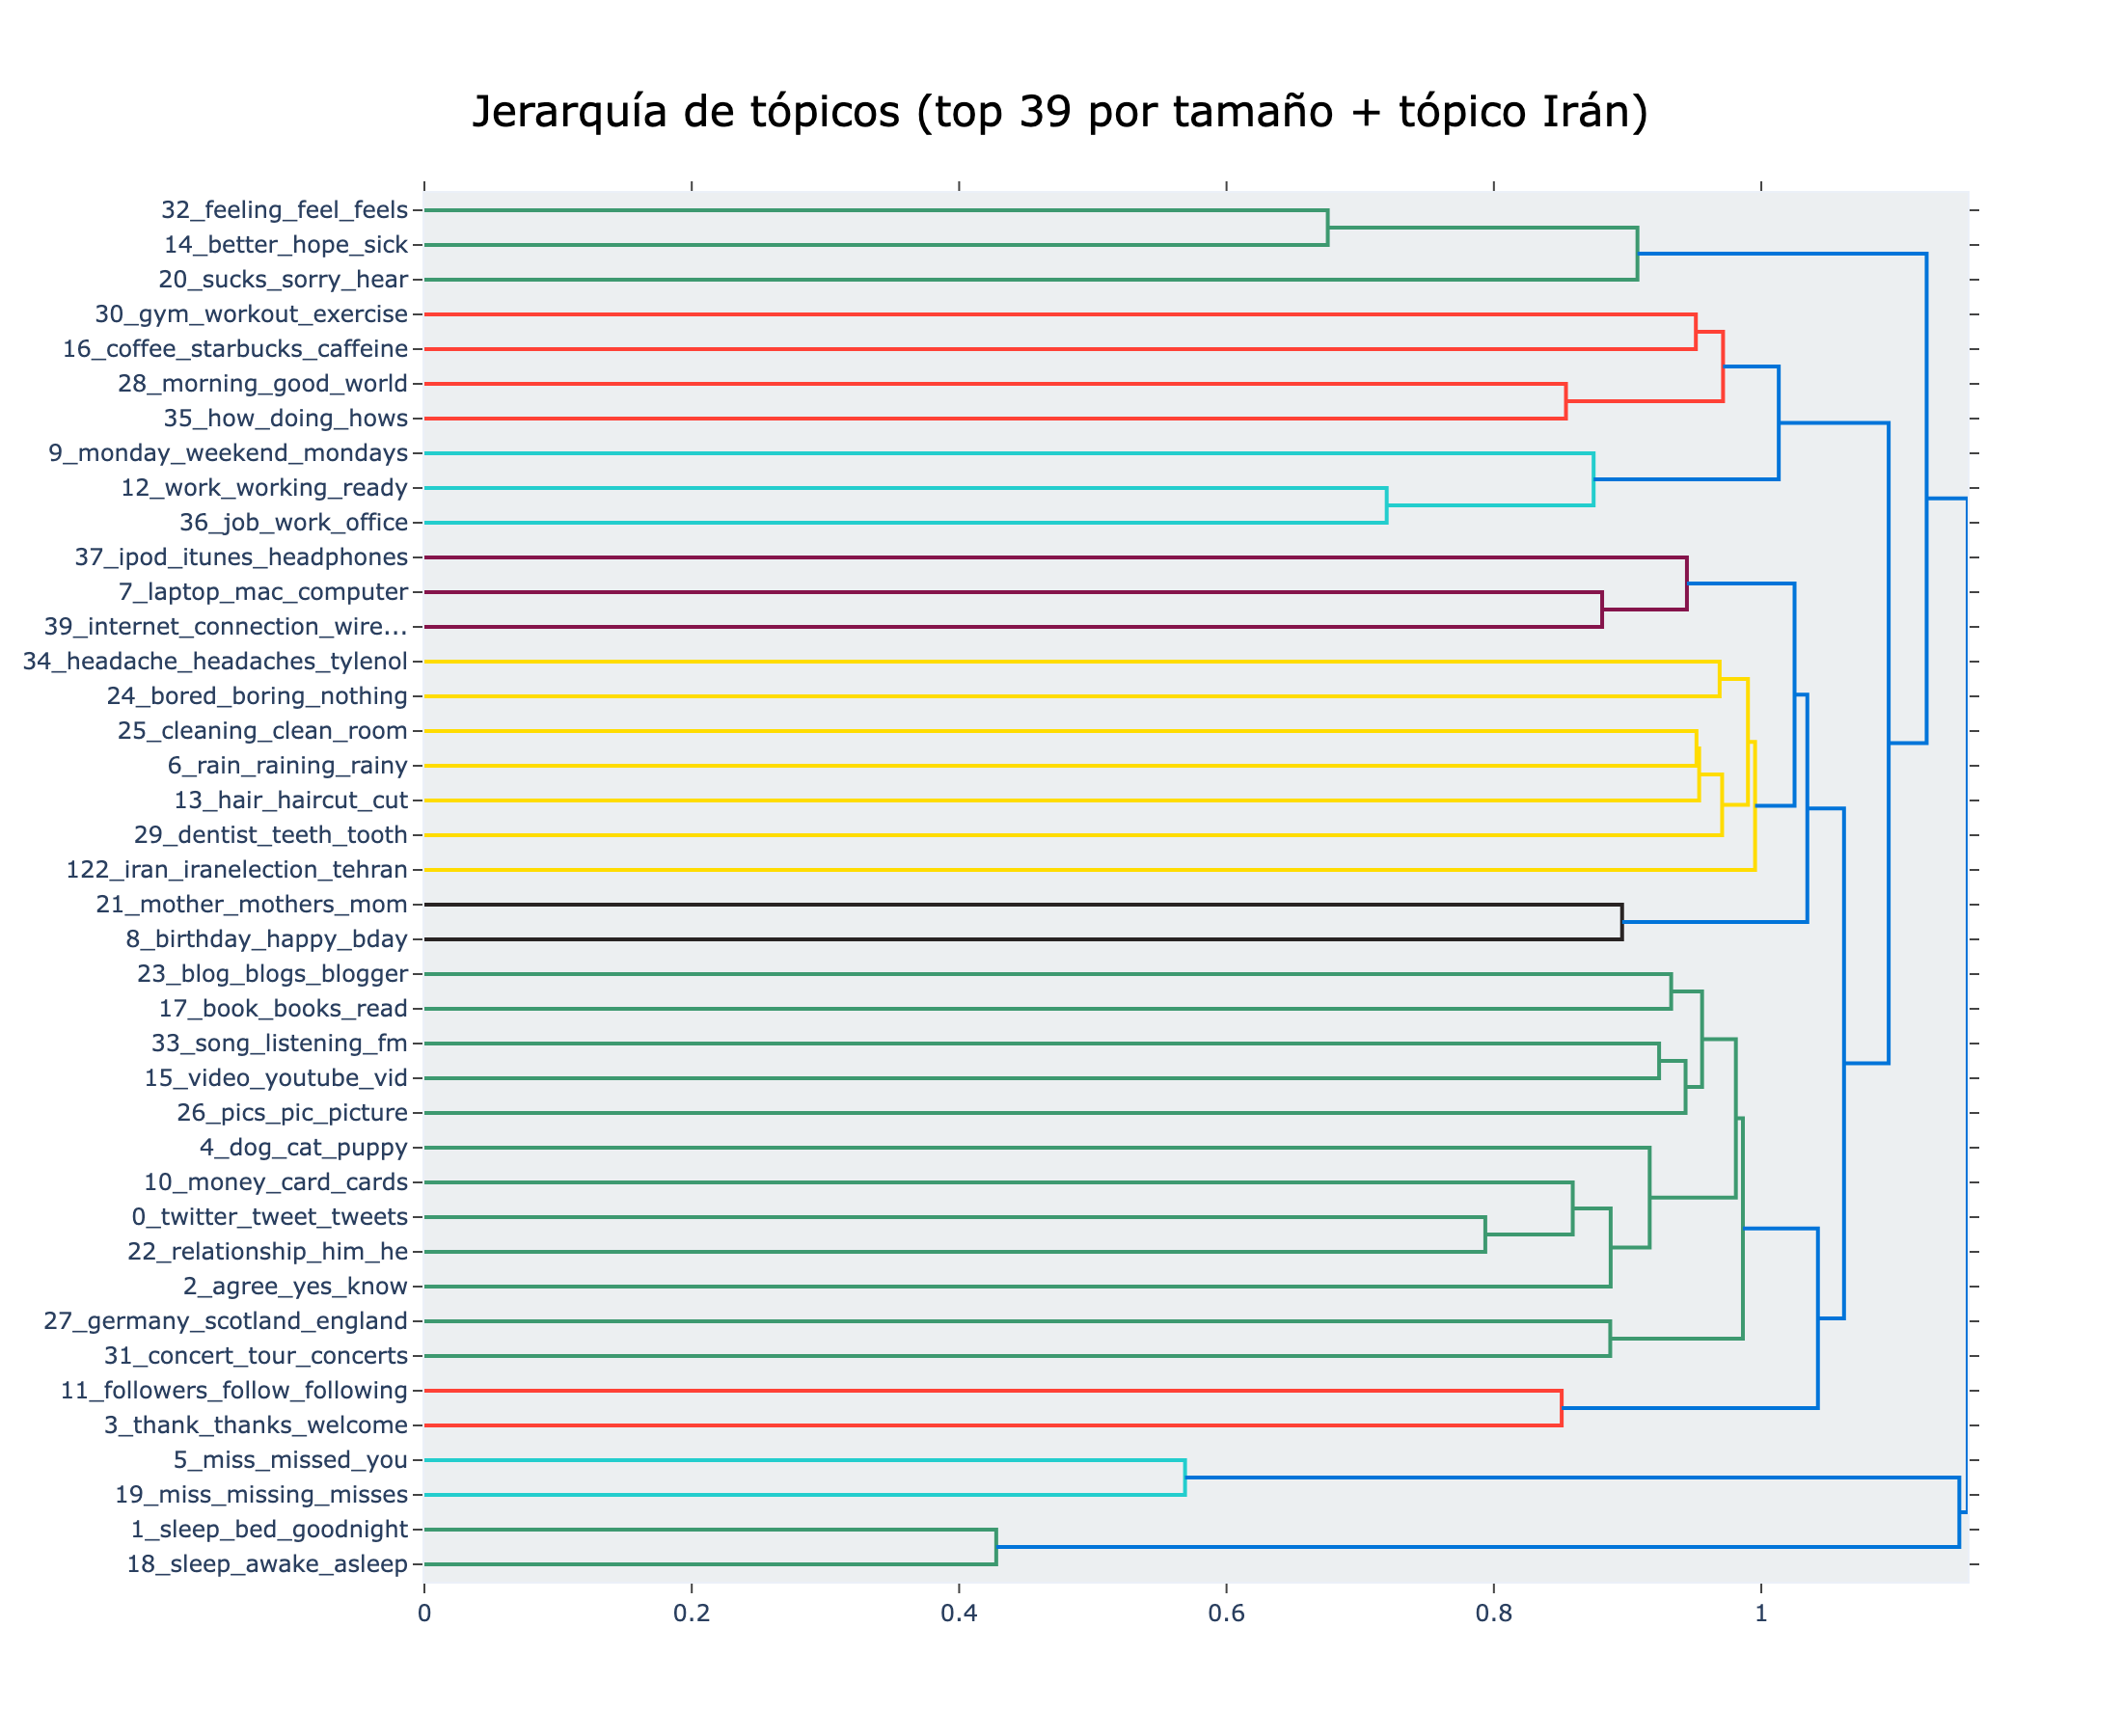

In [4]:
from IPython.display import Image

info_sizes = info[info["Topic"] != -1].sort_values("Count", ascending=False)
top_ids = info_sizes.head(39)["Topic"].tolist()
if iran_topic_id not in top_ids:
    top_ids.append(iran_topic_id)

hierarchical_topics = topic_model.hierarchical_topics(sample["text"].tolist())
fig = topic_model.visualize_hierarchy(topics=top_ids, hierarchical_topics=hierarchical_topics,
                                       title="Jerarquía de tópicos (top 39 por tamaño + tópico Irán)")

img_bytes = fig.to_image(format="png", width=1100, height=900, scale=2)
Image(img_bytes)

**Hallazgo:** el tópico de Irán (`122_iran_iranelection_tehran`) no se agrupa con otros tópicos de "crisis" o noticias — de hecho no hay ningún otro tópico de ese tipo entre los más grandes. Se agrupa junto a tópicos de queja cotidiana menor: dolor de cabeza (`headache_headaches_tylenol`), aburrimiento (`bored_boring_nothing`), lluvia (`rain_raining_rainy`), limpieza (`cleaning_clean_room`), dentista (`dentist_teeth_tooth`). Esto tiene sentido dado cómo se construye la jerarquía: agrupa por similitud de **vocabulario/tono** (`c-TF-IDF`), no por tema estricto — Irán comparte con esos tópicos un registro de queja/negatividad aunque no comparta tema, consistente con el \~86% de sentimiento negativo medido en la sección 6.

## 4. Evolución temporal del tópico (`topics_over_time`)

Se usa `topics_over_time()` para bucketizar por fecha sin re-clusterizar (reutiliza la asignación de tópicos ya calculada).

topics_over_time: 47.5s


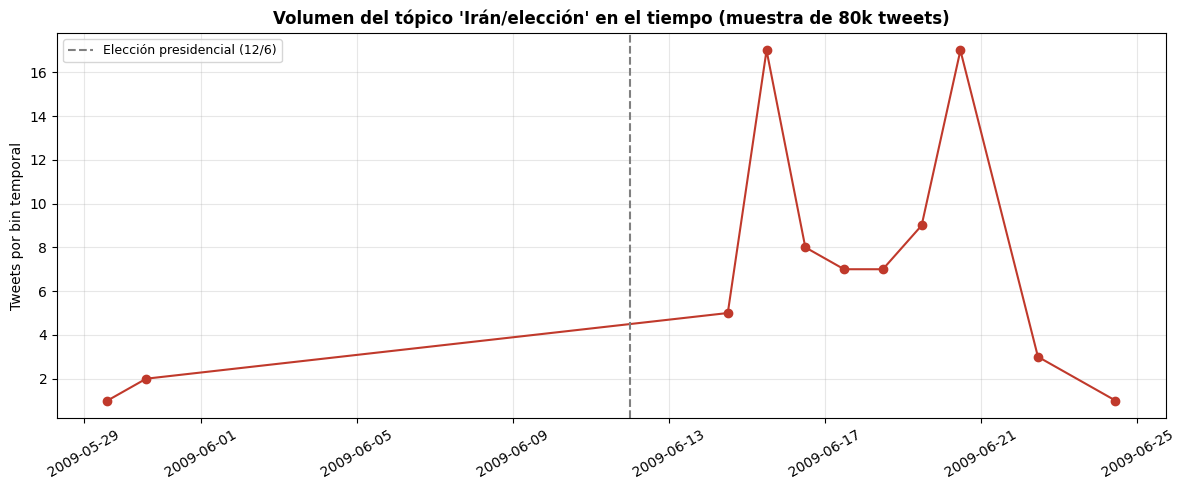

In [5]:
t0 = time.time()
evolucion = topic_model.topics_over_time(sample["text"].tolist(), sample["date"].tolist(), nr_bins=80)
print(f"topics_over_time: {time.time() - t0:.1f}s")

evolucion_iran = evolucion[evolucion["Topic"] == iran_topic_id].sort_values("Timestamp")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(evolucion_iran["Timestamp"], evolucion_iran["Frequency"], marker="o", color="#c0392b", linewidth=1.5)
ax.axvline(pd.Timestamp("2009-06-12"), color="gray", linestyle="--", label="Elección presidencial (12/6)")
ax.set_title("Volumen del tópico \'Irán/elección\' en el tiempo (muestra de 80k tweets)", fontsize=12, fontweight="bold")
ax.set_ylabel("Tweets por bin temporal")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Confirmación: el tópico es prácticamente inexistente antes del evento

Volumen diario directo del tópico (groupby simple sobre la muestra, más fácil de leer día a día que el binning de `topics_over_time`).

In [6]:
iran_tweets = sample[sample["topic"] == iran_topic_id]
volumen_diario = iran_tweets.groupby(iran_tweets["date"].dt.date).size()
print(volumen_diario.sort_index())

fecha_eleccion = pd.Timestamp("2009-06-12")
n_antes = (iran_tweets["date"] < fecha_eleccion).sum()
n_despues = (iran_tweets["date"] >= fecha_eleccion).sum()

print(f"\nTotal tweets del tópico: {len(iran_tweets)}")
print(f"Tweets antes del 12/6 (elección): {n_antes}")
print(f"Tweets desde el 12/6 en adelante:  {n_despues}")

print("\nEjemplos de tweets del pico (15-16/6):")
fechas_str = iran_tweets["date"].dt.date.astype(str)
ejemplos = iran_tweets[fechas_str.between("2009-06-15", "2009-06-16")]
for texto in ejemplos["text"].head(6):
    print(f"  - {texto}")

date
2009-05-30     1
2009-05-31     2
2009-06-15    15
2009-06-16    11
2009-06-17     8
2009-06-18     5
2009-06-19     8
2009-06-20    19
2009-06-21     4
2009-06-22     2
2009-06-23     1
2009-06-24     1
dtype: int64

Total tweets del tópico: 77
Tweets antes del 12/6 (elección): 3
Tweets desde el 12/6 en adelante:  74

Ejemplos de tweets del pico (15-16/6):
  - http://twitpic.com/7gfkz - Damn! Student shot with gun  HELP!!! #IranElection
  - #Iranelection Obama &quot;Deeply Troubled&quot;  By Iran Situation. Deeply troubled is a term I use for sore throat not cancer! http://bit.ly/11DmcE
  - On one hand is Fuzzball, on the other hand is Tehran  http://tinyurl.com/dhpol7
  - Can anyone check the Farsi info on the Ghalam News? My screen reader won't read Farsi!  #IranElection
  - Awake again... Seems Iran is still in recount !! Still, Healthier than english politics 
  - googled #iran9 and time, CNN, BBC, washingon post, Cnet news, AFP, comp.wrld, itnews all have article quoting #ir

**Hallazgo:** el tópico está prácticamente ausente hasta el 12/6 (fecha de la elección) y explota el 15/6, coincidiendo con el pico real de la cobertura de las protestas en Twitter (el hashtag `#IranElection` fue uno de los más usados de la plataforma en ese momento). Es una validación externa fuerte: un tópico que no existía antes de una fecha puntual aparece exactamente cuando ocurrió el evento real que lo originó.

## 6. Cruce con sentimiento

Se compara la polaridad promedio de los tweets del tópico Irán contra el promedio general de la muestra (que por diseño del dataset está balanceado \~50/50 entre positivo y negativo, promedio esperado ≈ 2.0 en la escala 0-4).

Polaridad promedio del tópico Irán: 0.57 (escala 0=negativo, 4=positivo)
Polaridad promedio de la muestra completa: 2.00
% de tweets negativos en el tópico Irán: 85.7%


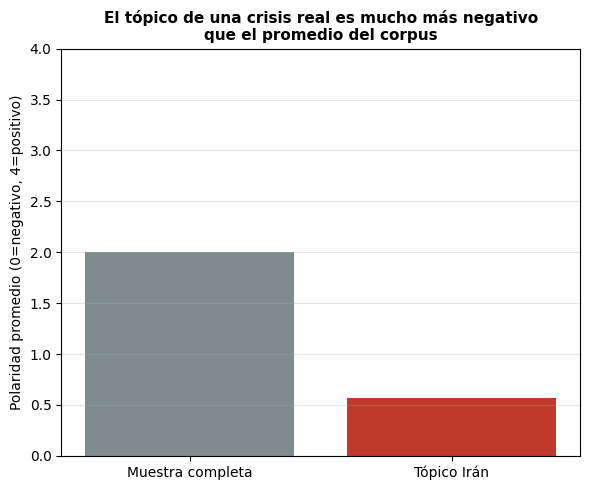

In [7]:
polaridad_iran = iran_tweets["polarity"].mean()
polaridad_general = sample["polarity"].mean()
pct_negativo_iran = (iran_tweets["polarity"] == 0).mean() * 100

print(f"Polaridad promedio del tópico Irán: {polaridad_iran:.2f} (escala 0=negativo, 4=positivo)")
print(f"Polaridad promedio de la muestra completa: {polaridad_general:.2f}")
print(f"% de tweets negativos en el tópico Irán: {pct_negativo_iran:.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Muestra completa", "Tópico Irán"], [polaridad_general, polaridad_iran], color=["#7f8c8d", "#c0392b"])
ax.set_ylim(0, 4)
ax.set_ylabel("Polaridad promedio (0=negativo, 4=positivo)")
ax.set_title("El tópico de una crisis real es mucho más negativo\nque el promedio del corpus", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Hallazgo:** el tópico Irán es abrumadoramente negativo (\~86% de los tweets) frente al \~50% esperado por el balance del dataset — conecta el análisis de tópicos con el resto del TP: no solo se detecta un evento real por su volumen, sino que su firma de sentimiento es coherente con la naturaleza del evento (una crisis política violenta).

## 7. Corrección de la hipótesis sobre Michael Jackson

En `00_lectura_y_discovery.ipynb` se planteó que el límite superior de fechas del dataset (25/6/2009) coincidía con la muerte de Michael Jackson, como posible validación adicional del enfoque. Los datos no confirman esta hipótesis, y vale la pena documentar por qué en vez de forzarla.

In [8]:
ultimo_timestamp = df["date"].max()
print(f"Último tweet del dataset: {ultimo_timestamp}")
print("Michael Jackson fue declarado muerto ~14:26 hora de Los Ángeles (PDT) el 25/6/2009.")
print("La recolección del dataset corta a las 10:28 (PDT) del mismo día -- ~4 horas ANTES del anuncio.")

mj_mask = sample["text"].str.contains("michael jackson|thriller|moonwalk", case=False, na=False, regex=True)
print(f"\nMenciones a Michael Jackson en la muestra: {mj_mask.sum()}")
for _, fila in sample[mj_mask][["date", "text"]].sort_values("date").iterrows():
    fecha_fila = fila["date"]
    texto_fila = fila["text"]
    print(f"  {fecha_fila}: {texto_fila}")

Último tweet del dataset: 2009-06-25 10:28:31
Michael Jackson fue declarado muerto ~14:26 hora de Los Ángeles (PDT) el 25/6/2009.
La recolección del dataset corta a las 10:28 (PDT) del mismo día -- ~4 horas ANTES del anuncio.



Menciones a Michael Jackson en la muestra: 6


  2009-05-10 05:38:39: @serafinowicz not so much of a&quot;Thriller &quot;really.the video was more of a horror genre (but that would have made a crap song).ta Ed Byrne 
  2009-05-22 06:53:30: #firstrecord are we talking actual RECORD?  (yeah i'm that old) Michael Jackson's Off The Wall.  I bet some y'all never had vinyl. 
  2009-05-31 04:58:32: I'm SO sad I'm going to miss MICHAEL JACKSON in London! 
  2009-05-31 07:27:57: http://twitpic.com/6c0qy - At the London theatre, Thriller Live. I like the interior &quot;old school&quot; 
  2009-06-20 14:16:25: im extremely sensitive to horrors thrillers etc so if people don't stop with deadmusic hash tag i will unfollow 
  2009-06-21 07:46:14: I hate Biochem bad, real bad Michael Jackson 


**Conclusión de la corrección:** las pocas menciones a Michael Jackson en la muestra son previas al 25/6 y hablan de su música/shows ("Thriller Live", "Off The Wall"), no de su muerte — consistente con que el corte de recolección del dataset ocurre horas antes del anuncio. La coincidencia de fecha del límite superior del dataset con el día de su muerte es real, pero no se traduce en un pico temático porque la ventana de recolección no llegó a cubrir la noticia. Se corrige esta afirmación en el README y en `00_lectura_y_discovery.ipynb`.

## 8. Conclusiones y decisiones

- **Confirmado**: el tópico de la elección/protestas en Irán es prácticamente inexistente antes del 12/6/2009 y explota el 15/6 — una validación externa clara de que BERTopic detecta eventos reales a partir de picos de volumen, y que el pico coincide con sentimiento fuertemente negativo (\~86%), coherente con la naturaleza del evento.
- **Triangulación independiente**: `00b_eda_contenido.ipynb` cuenta hashtags de forma simple (regex, sin ningún modelo de por medio) y `#iranelection` sale entre los más frecuentes del lado negativo del corpus completo (518 menciones) — dos métodos completamente distintos (clustering de embeddings vs. conteo de hashtags) coinciden en la misma señal, lo que da más confianza en el hallazgo que si viniera de un solo método.
- **Corregido**: la hipótesis sobre Michael Jackson no se sostiene — el dataset corta la recolección \~4 horas antes del anuncio de su muerte, por lo que no hay pico que detectar. Se documenta como hallazgo honesto en vez de forzar una conclusión que los datos no respaldan.
- **Muestra de 80k en vez de 1.6M completo**: decisión pragmática de cómputo (embeddings en CPU), documentada explícitamente — es un análisis exploratorio/diferenciador, no uno de los modelos de clasificación que la consigna exige entrenar sobre el archivo completo.
- **Reproducibilidad**: se fijó `random_state` en el `UMAP` interno de BERTopic tras detectar que la numeración de tópicos cambiaba entre corridas sin ese fijado.
- **Métrica obligatoria**: BERTopic usa similitud coseno en `c-TF-IDF` y en la reducción UMAP (`metric="cosine"` explícito acá), cerrando el uso de la métrica en un tercer contexto además de Word2Vec (`03`) y los embeddings promedio (`04`).